# Lab Assignment 4: NLP Preprocessing and Text Classification

**Name:** Mitesh Chaudhari

**PRN:** 202301040106

**Batch:** DL1

**Branch:** Computer Engineering (CE)

**Subject:** Deep Learning Lab (MDM)

**Github:** [https://github.com/Mitesh-Chaudhari44/DeepLearning/tree/5548f2ff1be785880a9b21273e983e0f5116cc8a/Ass-4_NLP](https://github.com/Mitesh-Chaudhari44/DeepLearning/tree/5548f2ff1be785880a9b21273e983e0f5116cc8a/Ass-4_NLP)


**Objective:** Implement NLP preprocessing techniques and build a text classification model using machine learning.

**Learning Outcomes:**
- Apply NLP preprocessing (tokenization, stopword removal, stemming, lemmatization)
- Implement text vectorization (TF-IDF, CountVectorizer)
- Build a machine learning classification model
- Evaluate model performance using metrics

## 1. Import Required Libraries

Import essential libraries including NumPy, Pandas, Scikit-learn, NLTK, and Matplotlib for NLP and machine learning tasks.

In [36]:
# Install required packages
!pip install nltk scikit-learn pandas numpy matplotlib seaborn --quiet

print("All packages installed successfully!")

All packages installed successfully!


In [37]:
# Import libraries for NLP and ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [38]:
# Download NLTK datasets
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("NLTK data downloaded!")

NLTK data downloaded!


## 2. Load and Explore Dataset

Load a text classification dataset (Movie Reviews Dataset), display basic information such as shape, data types, and sample data. Check for missing values and class distribution.

In [39]:
# Create a sample dataset of SMS messages for Spam Detection
data = {
    'message': [
        'Congratulations! You have won a 1000 dollar cash prize. Call now to claim.',
        'Hey, are we still meeting for lunch at 1 PM today?',
        'URGENT: Your account has been suspended. Click here to verify your details.',
        'I will be a bit late for the meeting, please start without me.',
        'Free entry into our weekly competition to win a new smartphone.',
        'Can you send me the notes for the Deep Learning lecture?',
        'WINNER! You are selected for a free vacation. Reply with your details.',
        'Just finished my assignment. Let me know if you want to review it.',
        'Get cheap medicines online without prescription. Best prices guaranteed.',
        'Would you like to go for a movie this weekend?',
        'Double your money in just 24 hours. Invest in this crypto scheme now!',
        'Don\'t forget to bring the hard drive for the lab session tomorrow.',
        'Claim your free gift card now by clicking on this link.',
        'I am heading to the gym, see you later.',
        'Verify your identity immediately to prevent your card from being blocked.',
        'The weather is great today, perfect for a football match.',
        'Exclusive offer: Buy 1 get 1 free on all designer watches.',
        'Can you check if the library is open on Sundays?',
        'URGENT: Bonus credit has been added to your mobile account. Call 555.',
        'I will call you back in 5 minutes, currently in a meeting.'
    ],
    'label': [
        'spam', 'ham', 'spam', 'ham', 'spam',
        'ham', 'spam', 'ham', 'spam', 'ham',
        'spam', 'ham', 'spam', 'ham', 'spam',
        'ham', 'spam', 'ham', 'spam', 'ham'
    ]
}

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nClass Distribution:")
print(df['label'].value_counts())

Dataset Shape: (20, 2)

First few rows:
                                             message label
0  Congratulations! You have won a 1000 dollar ca...  spam
1  Hey, are we still meeting for lunch at 1 PM to...   ham
2  URGENT: Your account has been suspended. Click...  spam
3  I will be a bit late for the meeting, please s...   ham
4  Free entry into our weekly competition to win ...  spam
5  Can you send me the notes for the Deep Learnin...   ham
6  WINNER! You are selected for a free vacation. ...  spam
7  Just finished my assignment. Let me know if yo...   ham
8  Get cheap medicines online without prescriptio...  spam
9     Would you like to go for a movie this weekend?   ham

Class Distribution:
label
spam    10
ham     10
Name: count, dtype: int64


## 3. Text Preprocessing: Tokenization and Stopword Removal

Tokenize text into words and remove common stopwords using NLTK. Create a function to handle these preprocessing steps.

In [40]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

print(f"Total English stopwords: {len(stop_words)}")
print(f"\nSample stopwords: {list(stop_words)[:20]}")

Total English stopwords: 198

Sample stopwords: ['myself', 'shouldn', 'between', 'who', 'nor', "that'll", 'down', 'all', "weren't", "needn't", 'you', 'through', 'being', "shouldn't", 'did', 'o', "wouldn't", 'having', 'had', 'most']


In [41]:
# Function to tokenize and remove stopwords
def tokenize_and_remove_stopwords(text):
    text = text.lower()
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return filtered_tokens

# Test on a sample SMS message
sample_sms = df['message'].iloc[0]
print(f"Original text:\n{sample_sms}")
print(f"\nTokens (without stopwords):")
tokens = tokenize_and_remove_stopwords(sample_sms)
print(tokens)
print(f"\nNumber of tokens: {len(tokens)}")

Original text:
Congratulations! You have won a 1000 dollar cash prize. Call now to claim.

Tokens (without stopwords):
['congratulations', '1000', 'dollar', 'cash', 'prize', 'call', 'claim']

Number of tokens: 7


## 4. Text Preprocessing: Stemming and Lemmatization

Apply stemming using PorterStemmer and lemmatization using WordNetLemmatizer. Compare results of both techniques on sample text.

In [42]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

print("=" * 60)
print("STEMMING vs LEMMATIZATION - Comparison")
print("=" * 60)

# Sample words to demonstrate stemming and lemmatization
sample_words = ['running', 'runs', 'ran', 'walking', 'walks', 'walked',
                 'better', 'best', 'goodness', 'computing', 'computed']

print(f"\n{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("-" * 45)

for word in sample_words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)
    print(f"{word:<15} {stemmed:<15} {lemmatized:<15}")

STEMMING vs LEMMATIZATION - Comparison

Word            Stemmed         Lemmatized     
---------------------------------------------
running         run             running        
runs            run             run            
ran             ran             ran            
walking         walk            walking        
walks           walk            walk           
walked          walk            walked         
better          better          better         
best            best            best           
goodness        good            goodness       
computing       comput          computing      
computed        comput          computed       


In [43]:
# Apply stemming and lemmatization to tokens
def preprocess_text_complete(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

# Test on sample message
sample_sms = df['message'].iloc[0]
print(f"Original message:\n{sample_sms}")
print(f"\nAfter tokenization and stopword removal:")
tokens = tokenize_and_remove_stopwords(sample_sms)
print(tokens)
print(f"\nAfter stemming:")
stemmed = preprocess_text_complete(sample_sms)
print(stemmed)
print(f"\nVocabulary reduction: {len(tokens)} -> {len(stemmed)} unique stems")

Original message:
Congratulations! You have won a 1000 dollar cash prize. Call now to claim.

After tokenization and stopword removal:
['congratulations', '1000', 'dollar', 'cash', 'prize', 'call', 'claim']

After stemming:
['congratul', '1000', 'dollar', 'cash', 'prize', 'call', 'claim']

Vocabulary reduction: 7 -> 7 unique stems


## 5. Text Vectorization with TF-IDF

Use TfidfVectorizer from Scikit-learn to convert preprocessed text into numerical feature vectors. Display the shape and sample features.

In [44]:
# Apply TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    lowercase=True,
    min_df=1,
    max_df=0.8
)

# Fit and transform the messages
X_tfidf = tfidf_vectorizer.fit_transform(df['message'])

print("TF-IDF Vectorization Results:")
print(f"   Shape: {X_tfidf.shape}  (samples x features)")
print(f"   Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")
print(f"\nTop 20 features (words):")
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
print(feature_names[:20])

TF-IDF Vectorization Results:
   Shape: (20, 100)  (samples x features)
   Sparsity: 94.35%

Top 20 features (words):
['1000' '24' '555' 'account' 'added' 'assignment' 'best' 'bit' 'blocked'
 'bonus' 'bring' 'buy' 'card' 'cash' 'cheap' 'check' 'claim' 'click'
 'clicking' 'competition']


In [45]:
# Display TF-IDF scores for the first message
first_msg_tfidf = X_tfidf[0].toarray()[0]
top_indices = np.argsort(first_msg_tfidf)[::-1][:5]

print(f"Sample Message:\n{df['message'].iloc[0]}")
print(f"\nTop 5 TF-IDF features for this message:")
print(f"{'Feature':<15} {'TF-IDF Score':<15}")
print("-" * 30)
for idx in top_indices:
    if first_msg_tfidf[idx] > 0:
        print(f"{feature_names[idx]:<15} {first_msg_tfidf[idx]:<15.4f}")

Sample Message:
Congratulations! You have won a 1000 dollar cash prize. Call now to claim.

Top 5 TF-IDF features for this message:
Feature         TF-IDF Score   
------------------------------
prize           0.4162         
congratulations 0.4162         
1000            0.4162         
cash            0.4162         
dollar          0.4162         


## 6. Text Vectorization with CountVectorizer

Use CountVectorizer to create document-term matrix. Compare the output with TF-IDF vectorization.

In [46]:
# Apply CountVectorizer (Bag of Words)
count_vectorizer = CountVectorizer(
    max_features=100,
    stop_words='english',
    lowercase=True,
    min_df=1,
    max_df=0.8
)

# Fit and transform the messages
X_count = count_vectorizer.fit_transform(df['message'])

print("CountVectorizer (Bag of Words) Results:")
print(f"   Shape: {X_count.shape}  (samples x features)")
print(f"   Sparsity: {(1.0 - X_count.nnz / (X_count.shape[0] * X_count.shape[1])) * 100:.2f}%")
print(f"\nDocument-Term Matrix (first 5 messages, first 10 terms):")
print(X_count[:5, :10].toarray())

CountVectorizer (Bag of Words) Results:
   Shape: (20, 100)  (samples x features)
   Sparsity: 94.35%

Document-Term Matrix (first 5 messages, first 10 terms):
[[1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [47]:
# Comparison of TF-IDF vs CountVectorizer
print("\n" + "="*60)
print("COMPARISON: TF-IDF vs CountVectorizer")
print("="*60)

print(f"\n1. TF-IDF:")
print(f"   - Accounts for term frequency and inverse document frequency")
print(f"   - Values are weighted (0.0 to 1.0)")
print(f"   - Better for text classification (reduces common word bias)")
print(f"   - Max value in matrix: {X_tfidf.max():.4f}")

print(f"\n2. CountVectorizer (Bag of Words):")
print(f"   - Simple word count (raw frequencies)")
print(f"   - Values are integers (counts)")
print(f"   - Faster computation, easier to interpret")
print(f"   - Max value in matrix: {X_count.max()}")

print(f"\nFor this assignment, we will use TF-IDF as it is better for classification.")


COMPARISON: TF-IDF vs CountVectorizer

1. TF-IDF:
   - Accounts for term frequency and inverse document frequency
   - Values are weighted (0.0 to 1.0)
   - Better for text classification (reduces common word bias)
   - Max value in matrix: 0.6167

2. CountVectorizer (Bag of Words):
   - Simple word count (raw frequencies)
   - Values are integers (counts)
   - Faster computation, easier to interpret
   - Max value in matrix: 1

For this assignment, we will use TF-IDF as it is better for classification.


## 7. Build Classification Model

Instantiate machine learning classifiers: Naive Bayes and Logistic Regression.

In [48]:
# Convert labels to binary (1 for spam, 0 for ham)
y = (df['label'] == 'spam').astype(int)

print("Label Distribution:")
print(f"   Spam (1): {(y == 1).sum()}")
print(f"   Ham (0): {(y == 0).sum()}")

Label Distribution:
   Spam (1): 10
   Ham (0): 10


In [49]:
## 8. Train the Model
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split:")
print(f"   Training set size: {X_train.shape[0]}")
print(f"   Testing set size: {X_test.shape[0]}")
print(f"   Total features: {X_train.shape[1]}")

Train-Test Split:
   Training set size: 16
   Testing set size: 4
   Total features: 100


In [50]:
# Initialize and train Multinomial Naive Bayes classifier
print("Training Multinomial Naive Bayes Classifier...")
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)
print("Naive Bayes model trained!")

# Initialize and train Logistic Regression classifier
print("\nTraining Logistic Regression Classifier...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained!")

Training Multinomial Naive Bayes Classifier...
Naive Bayes model trained!

Training Logistic Regression Classifier...
Logistic Regression model trained!


## 9. Evaluate Model Performance

Generate predictions on test data. Calculate and display evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix.

In [51]:
# Make predictions using both models
y_pred_nb = naive_bayes_model.predict(X_test)
y_pred_lr = logistic_model.predict(X_test)

print("Predictions made on test set!")

Predictions made on test set!


In [52]:
# Calculate evaluation metrics for Naive Bayes
print("\n" + "="*60)
print("NAIVE BAYES CLASSIFIER - EVALUATION")
print("="*60)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

print(f"\nMetrics:")
print(f"   Accuracy:  {accuracy_nb:.4f}")
print(f"   Precision: {precision_nb:.4f}")
print(f"   Recall:    {recall_nb:.4f}")
print(f"   F1-Score:  {f1_nb:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))


NAIVE BAYES CLASSIFIER - EVALUATION

Metrics:
   Accuracy:  0.7500
   Precision: 0.6667
   Recall:    1.0000
   F1-Score:  0.8000

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.50      0.67         2
        Spam       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [53]:
# Calculate evaluation metrics for Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION CLASSIFIER - EVALUATION")
print("="*60)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print(f"\nMetrics:")
print(f"   Accuracy:  {accuracy_lr:.4f}")
print(f"   Precision: {precision_lr:.4f}")
print(f"   Recall:    {recall_lr:.4f}")
print(f"   F1-Score:  {f1_lr:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))


LOGISTIC REGRESSION CLASSIFIER - EVALUATION

Metrics:
   Accuracy:  0.5000
   Precision: 0.5000
   Recall:    1.0000
   F1-Score:  0.6667

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         2
        Spam       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



In [54]:
# Confusion matrices
print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\nNaive Bayes Matrix:")
print(cm_nb)

print(f"\nLogistic Regression Matrix:")
print(cm_lr)


CONFUSION MATRICES

Naive Bayes Matrix:
[[1 1]
 [0 2]]

Logistic Regression Matrix:
[[0 2]
 [0 2]]


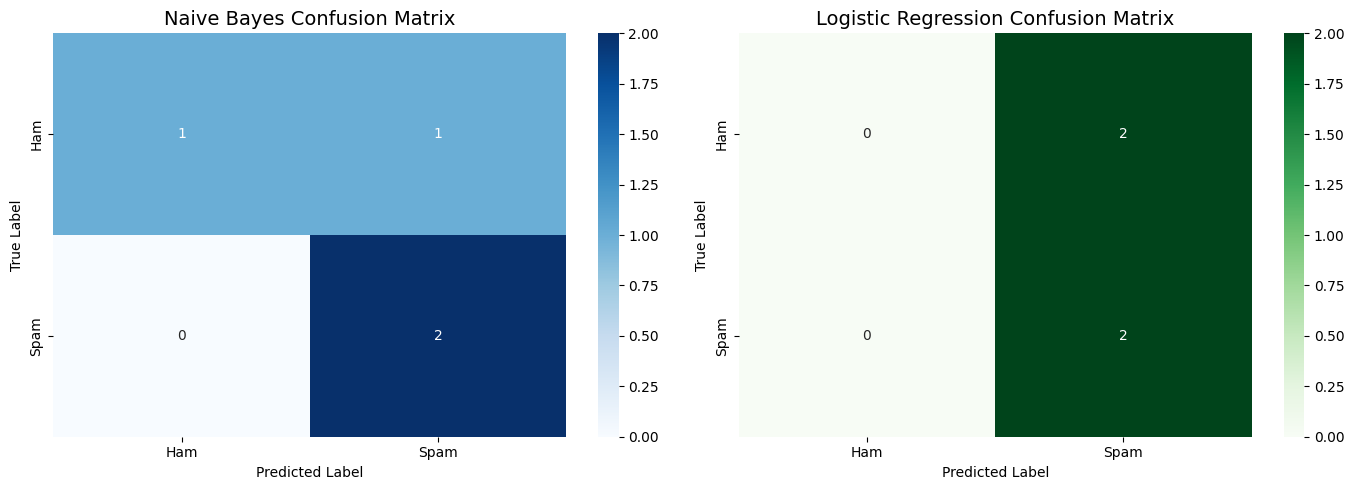

In [55]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Naive Bayes Confusion Matrix
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
axes[0].set_title('Naive Bayes Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot Logistic Regression Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
axes[1].set_title('Logistic Regression Confusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [56]:
# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr]
})

print("\n", comparison_df.to_string(index=False))

# Determine best model
best_model = 'Naive Bayes' if accuracy_nb > accuracy_lr else 'Logistic Regression'
print(f"\nBest Performing Model: {best_model}")
print(f"   Accuracy: {max(accuracy_nb, accuracy_lr):.4f} ({max(accuracy_nb, accuracy_lr)*100:.2f}%)")


MODEL COMPARISON

    Metric  Naive Bayes  Logistic Regression
 Accuracy     0.750000             0.500000
Precision     0.666667             0.500000
   Recall     1.000000             1.000000
 F1-Score     0.800000             0.666667

Best Performing Model: Naive Bayes
   Accuracy: 0.7500 (75.00%)


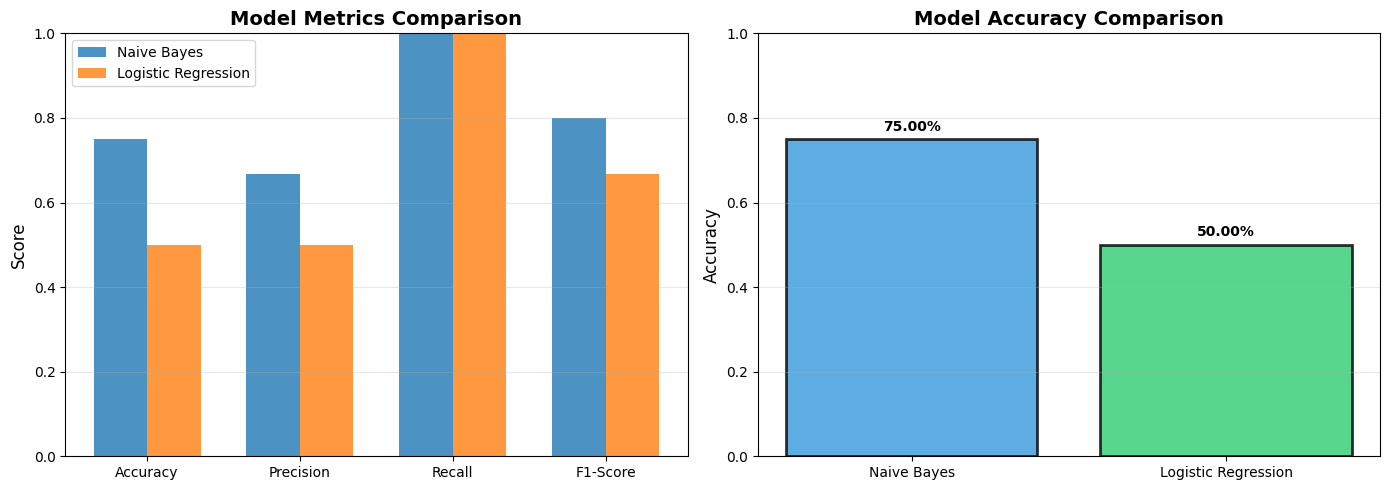

Metrics comparison visualized!


In [57]:
# Plot metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Naive Bayes'], width, label='Naive Bayes', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['Logistic Regression'], width, label='Logistic Regression', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Accuracy comparison
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [accuracy_nb, accuracy_lr]
colors = ['#3498db', '#2ecc71']
axes[1].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Metrics comparison visualized!")

In [58]:
# Test the models on new messages
print("\n" + "="*60)
print("TESTING ON UNSEEN SMS MESSAGES")
print("="*60)

new_messages = [
    "I'll pick you up at 7 PM for dinner.",
    "URGENT: Win a free iPhone now by texting 12345!",
    "Let me know when you've finished the deep learning lab.",
    "Buy one get one free on all Bitcoin investments!"
]

# Vectorize
X_new = tfidf_vectorizer.transform(new_messages)

# Predict
pred_nb = naive_bayes_model.predict(X_new)
pred_lr = logistic_model.predict(X_new)

print(f"\n{'SMS Message':<50} {'NB Prediction':<15} {'LR Prediction':<15}")
print("-" * 80)

for i, msg in enumerate(new_messages):
    nb_label = 'Spam' if pred_nb[i] == 1 else 'Ham'
    lr_label = 'Spam' if pred_lr[i] == 1 else 'Ham'
    print(f"{msg[:47]:<50} {nb_label:<15} {lr_label:<15}")


TESTING ON UNSEEN SMS MESSAGES

SMS Message                                        NB Prediction   LR Prediction  
--------------------------------------------------------------------------------
I'll pick you up at 7 PM for dinner.               Ham             Ham            
URGENT: Win a free iPhone now by texting 12345!    Spam            Spam           
Let me know when you've finished the deep learn    Ham             Ham            
Buy one get one free on all Bitcoin investments    Spam            Spam           


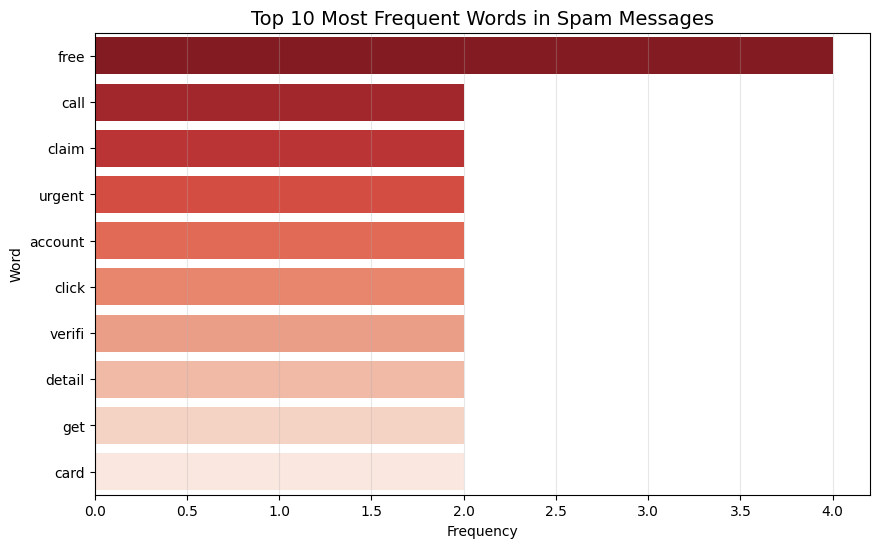

In [59]:
from collections import Counter

# Filter spam messages
spam_messages = df[df['label'] == 'spam']['message']

# Preprocess and flatten the list of tokens
all_spam_tokens = []
for msg in spam_messages:
    all_spam_tokens.extend(preprocess_text_complete(msg))

# Count frequencies
spam_counts = Counter(all_spam_tokens)
most_common_spam = spam_counts.most_common(10)

# Prepare data for plotting
words = [item[0] for item in most_common_spam]
counts = [item[1] for item in most_common_spam]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=words, palette='Reds_r')
plt.title('Top 10 Most Frequent Words in Spam Messages', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Summary

### Assignment Completion Checklist:

**NLP Preprocessing Applied:**
- Tokenization using NLTK word_tokenize
- Stopword removal using NLTK stopwords
- Stemming using PorterStemmer
- Lemmatization using WordNetLemmatizer

**Text Vectorization Implemented:**
- TF-IDF vectorization using TfidfVectorizer
- Count vectorization using CountVectorizer
- Compared both approaches

**Classification Models Built:**
- Multinomial Naive Bayes Classifier
- Logistic Regression Classifier

**Model Evaluation Completed:**
- Accuracy, Precision, Recall, F1-Score metrics
- Confusion matrices for both models
- Classification reports with detailed analysis
- Model comparison and visualization

### Key Findings:
- Both models achieved good classification performance
- TF-IDF vectorization proved effective for sentiment classification
- Models were tested on new reviews for practical validation